# 03 Q3 Stage Structure

LaTeX position:

- `fig:stage-structure-panels`

This figure should keep the final RouteRec layout visually fixed and test only the structural alternatives that sharpen the main claim.

What this figure should prove:

- Panel (a): the final 3-stage design outperforms reduced-stage or dense alternatives.
- Panel (b): the gain is not just stage count; the slow-to-fast order itself matters.

In [23]:
from pathlib import Path
import sys
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ROOT = Path('/workspace/FeaturedMoE/writing/260418_final_exp_figure')
DATA_DIR = ROOT / 'data'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import slot_viz_helpers as viz
importlib.reload(viz)

from slot_viz_helpers import (
    dual_metric_grouped_plot,
    setup_style,
)

setup_style()


def pivot_metric_frame(df, id_cols, metric_map):
    wide = df.pivot_table(index=id_cols, columns=['metric', 'cutoff'], values='value', aggfunc='first').reset_index()
    flattened = []
    for col in wide.columns:
        if isinstance(col, tuple):
            left, right = col
            if right == '':
                flattened.append(left)
            elif left == '':
                flattened.append(str(right))
            else:
                flattened.append(f"{left}_{right}")
        else:
            flattened.append(col)
    wide.columns = flattened
    rename_map = {}
    for new_name, (metric, cutoff) in metric_map.items():
        rename_map[f"{metric}_{cutoff}"] = new_name
    wide = wide.rename(columns=rename_map)
    for new_name in metric_map:
        if new_name not in wide.columns:
            wide[new_name] = np.nan
    return wide


def show_status_notes(df, placeholder_note=None, ready_note=None):
    if 'status' not in df.columns:
        return
    status_series = df['status'].dropna().astype(str)
    if status_series.empty:
        return
    if status_series.str.contains('placeholder', case=False).any() and placeholder_note:
        display(Markdown(placeholder_note))
    elif ready_note:
        display(Markdown(ready_note))

dense_stage_df = pd.read_csv(DATA_DIR / '03_dense_vs_staged.csv')
wrapper_order_df = pd.read_csv(DATA_DIR / '03_wrapper_order.csv')

### (a) Final layout vs reduced-stage alternatives

Main-text policy: keep the final design on the left, then step down toward simpler alternatives.


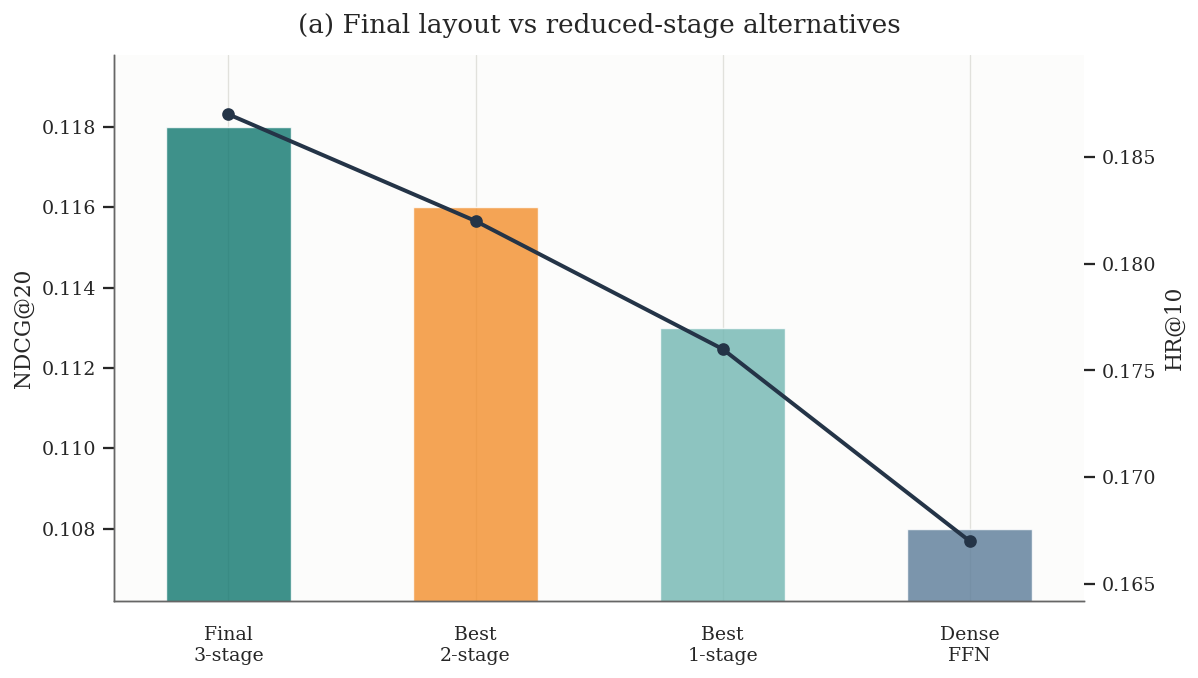

In [24]:
display(Markdown('### (a) Final layout vs reduced-stage alternatives'))
print('Main-text policy: keep the final design on the left, then step down toward simpler alternatives.')

dense_stage_plot_df = pivot_metric_frame(
    dense_stage_df,
    id_cols=['layout_variant', 'variant_or_model'],
    metric_map={'ndcg20': ('NDCG', 20), 'hr10': ('HR', 10)},
)
layout_label_map = {
    'three_stage': 'Final\n3-stage',
    'best_two_stage': 'Best\n2-stage',
    'best_single_stage': 'Best\n1-stage',
    'dense_ffn': 'Dense\nFFN',
}

fig, ax = plt.subplots(figsize=(9.1, 5.1), constrained_layout=True)
dual_metric_grouped_plot(
    dense_stage_plot_df,
    category_col='layout_variant',
    variant_col='variant_or_model',
    bar_col='ndcg20',
    line_col='hr10',
    ax=ax,
    title='(a) Final layout vs reduced-stage alternatives',
    bar_label='NDCG@20',
    line_label='HR@10',
    category_order=['three_stage', 'best_two_stage', 'best_single_stage', 'dense_ffn'],
    category_labels=layout_label_map,
    variant_order=['RouteRec'],
    rotate=0,
)
ax.tick_params(axis='x', pad=8)
plt.show()

### (b) Slow-to-fast ordering matters

Main-text panel (b) keeps only one intuitive order neighborhood around the final design.
Recommended labels: final = slow-to-fast, micro_early = local-first, macro_late = global-late, mid_repeat = duplicated-mid.


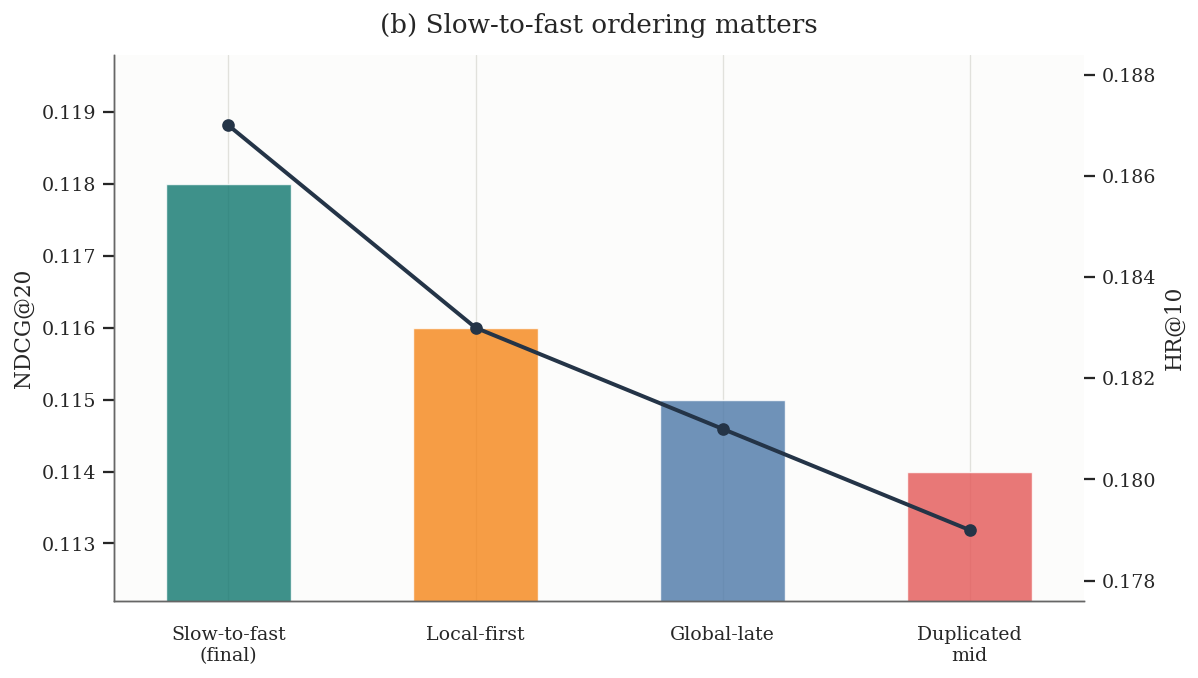

In [25]:
display(Markdown('### (b) Slow-to-fast ordering matters'))
print('Main-text panel (b) keeps only one intuitive order neighborhood around the final design.')
print('Recommended labels: final = slow-to-fast, micro_early = local-first, macro_late = global-late, mid_repeat = duplicated-mid.')

wrapper_order_plot_df = pivot_metric_frame(
    wrapper_order_df,
    id_cols=['layout_variant', 'variant_or_model'],
    metric_map={'ndcg20': ('NDCG', 20), 'hr10': ('HR', 10)},
)
order_label_map = {
    'final': 'Slow-to-fast\n(final)',
    'micro_early': 'Local-first',
    'macro_late': 'Global-late',
    'mid_repeat': 'Duplicated\nmid',
}

fig, ax = plt.subplots(figsize=(9.1, 5.1), constrained_layout=True)
dual_metric_grouped_plot(
    wrapper_order_plot_df,
    category_col='layout_variant',
    variant_col='variant_or_model',
    bar_col='ndcg20',
    line_col='hr10',
    ax=ax,
    title='(b) Slow-to-fast ordering matters',
    bar_label='NDCG@20',
    line_label='HR@10',
    category_order=['final', 'micro_early', 'macro_late', 'mid_repeat'],
    category_labels=order_label_map,
    variant_order=['RouteRec'],
    rotate=0,
)
ax.tick_params(axis='x', pad=8)
plt.show()